### Molecular reaction energies



#### O<sub>2</sub> dissociation



The first reaction we consider is a simple dissociation of oxygen molecule into two oxygen atoms: O<sub>2</sub> &rarr; 2O. The dissociation energy is pretty straightforward to define: it is the energy of the products minus the energy of the reactant. $D = 2*E_O - E_{O_2}$. It would appear that we simply calculate the energy of an oxygen atom, and the energy of an oxygen molecule and evaluate the formula. Let us do that.



##### Simple estimate of O<sub>2</sub> dissociation energy



In [1]:
from vasp import Vasp
from ase import Atom, Atoms

atoms = Atoms([Atom('O', [5, 5, 5])],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O',
            xc='PBE',
            encut=400,
            ismear=0,
            atoms=atoms)

E_O = atoms.get_potential_energy()

# now relaxed O2 dimer
atoms = Atoms([Atom('O', [5, 5, 5]),
               Atom('O', [6.22, 5, 5])],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O2',
            xc='PBE',
            encut=400,
            ismear=0,
            ibrion=2,
            nsw=10,
            atoms=atoms)

E_O2 = atoms.get_potential_energy()

if None not in (E_O, E_O2):
    print('O2 -> 2O  D = {0:1.3f} eV'.format(2 * E_O - E_O2))

O2 -> 2O  D = 8.619 eV


The answer we have obtained is way too high! Experimentally the dissociation energy is about 5.2 eV (need reference), which is **very** different than what we calculated! Let us consider some factors that contribute to this error.

We implicitly neglected spin-polarization in the example above. That could be a problem, since the O<sub>2</sub> molecule can be in one of two spin states, a singlet or a triplet, and these should have different energies. Furthermore, the oxygen atom can be a singlet or a triplet, and these would have different energies. To account for spin polarization, we have to tell VASP to use spin-polarization, and give initial guesses for the magnetic moments of the atoms. Let us try again with spin polarization.



##### Estimating O<sub>2</sub> dissociation energy with spin polarization in triplet ground states



To tell VASP to use spin-polarization we use [BROKEN LINK: incar:ISPIN]=2, and we set initial guesses for magnetic moments on the atoms with the magmom keyword. In a triplet state there are two electrons with spins of the same sign.



In [2]:
from vasp import Vasp
from ase import Atom, Atoms

atoms = Atoms([Atom('O', [5, 5, 5], magmom=2)],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O-sp-triplet',
            xc='PBE',
            encut=400,
            ismear=0,
            ispin=2,  # turn spin-polarization on
            atoms=atoms)

E_O = atoms.get_potential_energy()


print('Magnetic moment on O = {0} Bohr'
      ' magnetons'.format(atoms.get_magnetic_moment()))

# now relaxed O2 dimer
atoms = Atoms([Atom('O', [5,    5, 5], magmom=1),
               Atom('O', [6.22, 5, 5], magmom=1)],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O2-sp-triplet',
            xc='PBE',
            encut=400,
            ismear=0,
            ispin=2,   # turn spin-polarization on
            ibrion=2,  # make sure we relax the geometry
            nsw=10,
            atoms=atoms)

E_O2 = atoms.get_potential_energy()

# verify magnetic moment
print('Magnetic moment on O2 = {0} Bohr'
      ' magnetons'.format(atoms.get_magnetic_moment()))

if None not in (E_O, E_O2):
    print('O2 -> 2O  D = {0:1.3f} eV'.format(2 * E_O - E_O2))

Magnetic moment on O = 1.0 Bohr magnetons
Magnetic moment on O2 = 2.0 Bohr magnetons
O2 -> 2O  D = 6.746 eV


This is much closer to accepted literature values for the DFT-GGA $O_2$ dissociation energy. It is still more than 1 eV above an experimental value, but most of that error is due to the GGA exchange correlation functional. Some additional parameters that might need to be checked for convergence are the SIGMA value (it is probably too high for a molecule), as well as the cutoff energy. Oxygen is a "hard" atom that requires a high cutoff energy to achieve high levels of convergence.



###### Looking at the two spin densities



In a spin-polarized calculation there are actually two electron densities: one for spin-up and one for spin-down. We will look at the differences in these two through the density of states.



number of up states = 6.999684295747544
number of down states = 6.999684295747544


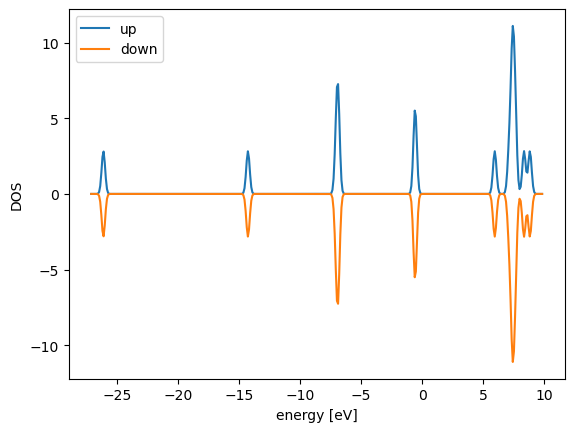

In [ ]:
from vasp import Vasp
from ase.dft.dos import *

calc = Vasp(label='molecules/O2-sp-triplet')

dos = DOS(calc, width=0.2)
d_up = dos.get_dos(spin=0)
d_down = dos.get_dos(spin=1)
e = dos.get_energies()

ind = e <= 0.0
# integrate up to 0eV
print('number of up states = {0}'.format(np.trapz(d_up[ind], e[ind])))
print('number of down states = {0}'.format(np.trapz(d_down[ind], e[ind])))

import pylab as plt
plt.plot(e, d_up,
         e, -d_down)
plt.xlabel('energy [eV]')
plt.ylabel('DOS')
plt.legend(['up', 'down'])

You can see in Figure ref:fig:o2-sp-dos that there are two different densities of states for the two spins. One has 7 electrons in it (the blue lines), and the other has 5 electrons in it (the green line). The difference of two electrons leads to the magnetic moment of 2 which we calculated earlier. Remember that only peaks in the DOS below the Fermi level are occupied. It is customary to set the Fermi level to 0 eV in DOS plots. The peaks roughly correspond to electrons. For example, the blue peak between -25 and -30 eV corresponds to one electron, in a 1s orbital, where as the blue peak between -5 and -10 eV corresponds to three electrons.



##### Convergence study of the O<sub>2</sub> dissociation energy



O2 -> 2O encut = 250  D = 6.776 eV
O2 -> 2O encut = 300  D = 6.804 eV
O2 -> 2O encut = 350  D = 6.785 eV
O2 -> 2O encut = 400  D = 6.746 eV
O2 -> 2O encut = 450  D = 6.727 eV
O2 -> 2O encut = 500  D = 6.725 eV
O2 -> 2O encut = 550  D = 6.728 eV


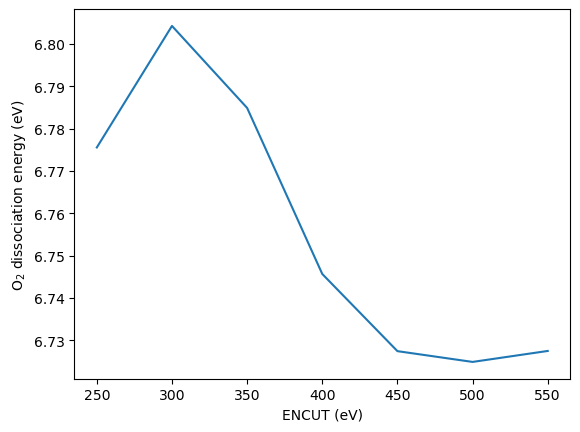

In [26]:
from vasp import Vasp
from ase import Atom, Atoms
encuts = [250, 300, 350, 400, 450, 500, 550]

D = []
for encut in encuts:
    atoms = Atoms([Atom('O', [5, 5, 5], magmom=2)],
                  cell=(10, 10, 10))

    calc = Vasp('molecules/O-sp-triplet-{0}'.format(encut),
                xc='PBE',
                encut=encut,
                ismear=0,
                ispin=2,
                atoms=atoms)

    E_O = atoms.get_potential_energy()

    # now relaxed O2 dimer
    atoms = Atoms([Atom('O', [5,    5, 5], magmom=1),
                   Atom('O', [6.22, 5, 5], magmom=1)],
                  cell=(10, 10, 10))

    calc = Vasp('molecules/O2-sp-triplet-{0}'.format(encut),
                xc='PBE',
                encut=encut,
                ismear=0,
                ispin=2,   # turn spin-polarization on
                ibrion=2,  # this turns relaxation on
                nsw=10,
                atoms=atoms)

    E_O2 = atoms.get_potential_energy()

    if None not in (E_O, E_O2):
        d = 2*E_O - E_O2
        D.append(d)
        print('O2 -> 2O encut = {0}  D = {1:1.3f} eV'.format(encut, d))


import matplotlib.pyplot as plt
plt.plot(encuts, D)
plt.xlabel('ENCUT (eV)')
plt.ylabel('O$_2$ dissociation energy (eV)');

Based on these results (Figure ref:fig:o2-encut), you could argue the dissociation energy is converged to about 2 meV at a planewave cutoff of 450 eV, and within 50 meV at 350 eV cutoff. You have to decide what an appropriate level of convergence is. Note that increasing the planewave cutoff significantly increases the computational time, so you are balancing level of convergence with computational speed. It would appear that planewave cutoff is not the cause for the discrepancy between our calculations and literature values.



In [28]:
import os

encuts = [250, 300, 350, 400, 450, 500, 550]
print('encut (eV)            Total CPU time')
print('--------------------------------------------------------')

for encut in encuts:
    OUTCAR = 'molecules/O2-sp-triplet-{0}/OUTCAR'.format(encut)
    if os.path.exists(OUTCAR):
        with open(OUTCAR) as f:
            for line in f:
                if 'Total CPU time' in line:
                    print(f'{encut:4d}                  {line.strip().split()[-1]} seconds')
                    break
    else:
        print(f'{encut:4d}                  [calculation not found]')


encut (eV)            Total CPU time
--------------------------------------------------------
 250                  7.892 seconds
 300                  10.286 seconds
 350                  14.238 seconds
 400                  17.892 seconds
 450                  23.054 seconds
 500                  25.798 seconds
 550                  29.507 seconds


##### Illustration of the effect of SIGMA



The methodology for extrapolation of the total energy to absolute zero is
only valid for a continuous density of states at the Fermi level
cite:Kresse199615. Consequently, it should not be used for
semiconductors, molecules or atoms. In VASP, this means a very small
Fermi temperature (SIGMA) should be used.  The O<sub>2</sub> dissociation energy
as a function of SIGMA is shown in Figure
ref:fig:sigma-o2-diss. A variation of nearly 0.2 eV is seen from the
default Fermi temperature of $k_bT=0.2$ eV and the value of
$k_bT=0.0001$ eV. However, virtually no change was observed for a
hydrogen atom or molecule or for an oxygen molecule as a function of
the Fermi temperature. It is recommended that the total energy be
calculated at several values of the Fermi temperature to make sure the
total energy is converged with respect to the Fermi temperature.

We were not careful in selecting a good value for [BROKEN LINK: incar:SIGMA] in the calculations above. The default value of SIGMA is 0.2, which may be fine for metals, but it is not correct for molecules. SIGMA is the broadening factor used to smear the electronic density of states at the Fermi level. For a metal with a continuous density of states this is appropriate, but for molecules with discrete energy states it does not make sense. We are somewhat forced to use the machinery designed for metals on molecules. The solution is to use a very small SIGMA. Ideally you would use SIGMA=0, but that is not practical for convergence reasons, so we try to find what is small enough. Let us examine the effect of SIGMA on the dissociation energy here.



O2 -> 2O sigma = 0.2  D = 6.669 eV
O2 -> 2O sigma = 0.1  D = 6.746 eV
O2 -> 2O sigma = 0.05  D = 6.784 eV
O2 -> 2O sigma = 0.02  D = 6.807 eV
O2 -> 2O sigma = 0.01  D = 6.815 eV
O2 -> 2O sigma = 0.001  D = 6.822 eV


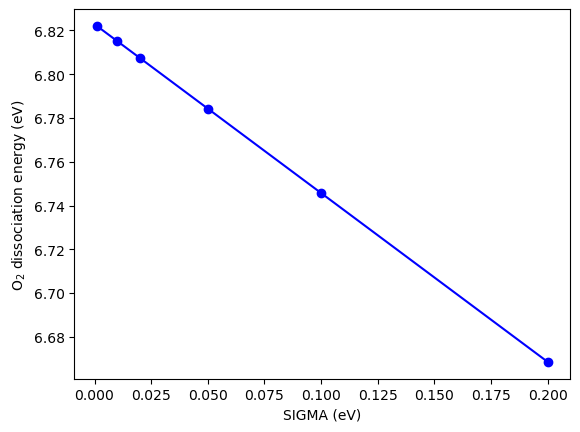

In [29]:
from vasp import Vasp
from ase import Atom, Atoms

sigmas = [0.2, 0.1, 0.05, 0.02, 0.01, 0.001]

D = []
for sigma in sigmas:
    atoms = Atoms([Atom('O',[5, 5, 5], magmom=2)],
                  cell=(10, 10, 10))

    calc = Vasp(label='molecules/O-sp-triplet-sigma-{0}'.format(sigma),
                xc='PBE',
                encut=400,
                ismear=0,
                sigma=sigma,
                ispin=2,
                atoms=atoms)

    E_O = atoms.get_potential_energy()

    # now relaxed O2 dimer
    atoms = Atoms([Atom('O',[5,    5, 5],magmom=1),
                   Atom('O',[6.22, 5, 5],magmom=1)],
                  cell=(10, 10, 10))

    calc = Vasp(label='molecules/O2-sp-triplet-sigma-{0}'.format(sigma),
                xc='PBE',
                encut=400,
                ismear=0,
                sigma=sigma,
                ispin=2,   # turn spin-polarization on
                ibrion=2,  # make sure we relax the geometry
                nsw=10,
                atoms=atoms)

    E_O2 = atoms.get_potential_energy()

    if None not in (E_O, E_O2):
        d = 2 * E_O - E_O2
        D.append(d)
        print('O2 -> 2O sigma = {0}  D = {1:1.3f} eV'.format(sigma, d))

import matplotlib.pyplot as plt
plt.plot(sigmas, D, 'bo-')
plt.xlabel('SIGMA (eV)')
plt.ylabel('O$_2$ dissociation energy (eV)');

Clearly SIGMA has an effect, but it does not move the dissociation energy closer to the literature values!



##### Estimating singlet oxygen dissociation energy



Finally, let us consider the case where each species is in the singlet state.



In [33]:
from vasp import Vasp
from ase import Atom, Atoms

atoms = Atoms([Atom('O', [5, 5, 5], magmom=0)],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O-sp-singlet',
            xc='PBE',
            encut=400,
            ismear=0,
            ispin=2,
            nupdown=0,  # Force singlet: N_up - N_down = 0
            atoms=atoms)

E_O = atoms.get_potential_energy()

print('Magnetic moment on O = {0} Bohr'
      ' magnetons'.format(atoms.get_magnetic_moment()))

# now relaxed O2 dimer
atoms = Atoms([Atom('O', [5, 5, 5], magmom=1),
               Atom('O', [6.22, 5, 5], magmom=-1)],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O2-sp-singlet',
            xc='PBE',
            encut=400,
            ismear=0,
            ispin=2,  # turn spin-polarization on
            ibrion=2, # make sure we relax the geometry
            nupdown=0,  # Force singlet: N_up - N_down = 0
            nsw=10,
            atoms=atoms)

E_O2 = atoms.get_potential_energy()

# verify magnetic moment
print('O2 molecule magnetic moment = ', atoms.get_magnetic_moment())

if None not in (E_O, E_O2):
    print('O2 -> 2O  D = {0:1.3f} eV'.format(2 * E_O - E_O2))

Magnetic moment on O = 0.0 Bohr magnetons
O2 molecule magnetic moment =  0.0
O2 -> 2O  D = 8.619 eV


Let us directly compare their total energies:



In [34]:
from vasp import Vasp

calc = Vasp(label='molecules/O2-sp-singlet')
print('singlet: {0} eV'.format(calc.potential_energy))

calc = Vasp(label='molecules/O2-sp-triplet')
print('triplet: {0} eV'.format(calc.potential_energy))

singlet: -8.77355744 eV
triplet: -9.84813402 eV


You can see here the triplet state has an energy that is 1 eV more stable than the singlet state.



##### Estimating triplet oxygen dissociation energy with low symmetry



It has been suggested that breaking spherical symmetry of the atom can result in lower energy of the atom. The symmetry is broken by putting the atom off-center in a box. We will examine the total energy of an oxygen atom in a few geometries. First, let us consider variations of a square box.



In [9]:
from vasp import Vasp
from ase import Atom, Atoms

# square box origin
atoms = Atoms([Atom('O', [0, 0, 0], magmom=2)],
              cell=(10, 10, 10))

pars = dict(xc='PBE',
            encut=400,
            ismear=0,
            sigma=0.01,
            ispin=2)

calc = Vasp(label='molecules/O-square-box-origin',
            atoms=atoms, **pars)

print('Square box (origin): E = {0} eV'.format(atoms.get_potential_energy()))

# square box center
atoms = Atoms([Atom('O', [5, 5, 5], magmom=2)],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O-square-box-center',
            atoms=atoms, **pars)
print('Square box (center): E = {0} eV'.format(atoms.get_potential_energy()))

# square box random
atoms = Atoms([Atom('O', [2.13, 7.32, 1.11], magmom=2)],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O-square-box-random',
            atoms=atoms, **pars)

print('Square box (random): E = {0} eV'.format(atoms.get_potential_energy()))

Square box (origin): E = -1.51651409 eV
Square box (center): E = -1.51651344 eV
Square box (random): E = -1.5152472 eV


There is no significant difference in these energies. The origin and center calculations are identical in energy. The meV variation in the random calculation is negligible. Now, let us consider some non-square boxes.



In [10]:
# calculate O atom energy in orthorhombic boxes
from vasp import Vasp
from ase import Atom, Atoms

# orthorhombic box origin
atoms = Atoms([Atom('O', [0, 0, 0], magmom=2)],
              cell=(8, 9, 10))

calc = Vasp(label='molecules/O-orthorhombic-box-origin',
            xc='PBE',
            encut=400,
            ismear=0,
            sigma=0.01,
            ispin=2,
            atoms=atoms)

print('Orthorhombic box (origin): E = {0} eV'.format(atoms.get_potential_energy()))

# orthorhombic box center
atoms = Atoms([Atom('O', [4, 4.5, 5], magmom=2)],
              cell=(8, 9, 10))
calc = Vasp(label='molecules/O-orthorhombic-box-center',
            xc='PBE',
            encut=400,
            ismear=0,
            sigma=0.01,
            ispin=2,
            atoms=atoms)

print('Orthorhombic box (center): E = {0} eV'.format(atoms.get_potential_energy()))

# orthorhombic box random
atoms = Atoms([Atom('O', [2.13, 7.32, 1.11], magmom=2)],
              cell=(8, 9, 10))

calc = Vasp(label='molecules/O-orthorhombic-box-random',
            xc='PBE',
            encut=400,
            ismear=0,
            sigma=0.01,
            ispin=2,
            atoms=atoms)

print('Orthorhombic box (random): E = {0} eV'.format(atoms.get_potential_energy()))

Orthorhombic box (origin): E = -1.89366996 eV
Orthorhombic box (center): E = -1.89367391 eV
Orthorhombic box (random): E = -1.89312787 eV


There doesn't seem to be a big difference here. It used to be more significant (10+ years ago).


In [11]:
from vasp import Vasp
from ase import Atom, Atoms

atoms = Atoms([Atom('O', [5.1, 4.2, 6.1], magmom=2)],
              cell=(8, 9, 10))

calc = Vasp(label='molecules/O-sp-triplet-lowsym',
            xc='PBE',
            encut=400,
            ismear=0,
            sigma=0.01,
            ispin=2,
            atoms=atoms)

E_O = atoms.get_potential_energy()
print('Magnetic moment on O = {0} Bohr  magnetons'.format(atoms.get_magnetic_moment()))

# now relaxed O2 dimer
atoms = Atoms([Atom('O', [5,    5, 5], magmom=1),
               Atom('O', [6.22, 5, 5], magmom=1)],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O2-sp-triplet',
            xc='PBE',
            encut=400,
            ismear=0,
            sigma=0.01,
            ispin=2,   # turn spin-polarization on
            ibrion=2,  # make sure we relax the geometry
            nsw=10,
            atoms=atoms)

E_O2 = atoms.get_potential_energy()
# verify magnetic moment
print('Magnetic moment on O2 = {0} Bohr magnetons'.format(atoms.get_magnetic_moment()))


if None not in (E_O, E_O2):
    print('E_O: ', E_O)
    print('O2 -> 2O  D = {0:1.3f} eV'.format(2 * E_O - E_O2))

Magnetic moment on O = 1.0 Bohr  magnetons
Magnetic moment on O2 = 2.0 Bohr magnetons
E_O:  -1.8931451
O2 -> 2O  D = 6.062 eV


This actually agrees within 30-50 meV of reported literature values, although still nearly an eV greater than the experimental dissociation energy. Note that with a different "random" position, we get the lower energy for the O atom. All the disagreement we had been seeing was apparently in the O atom energy. So, if you do not need the dissociation energy in your analysis, you will not see the error. Also note that this error is specific to there being a spherical atom in a symmetric cell. This is not a problem for most molecules, which are generally non-spherical.



##### Verifying the magnetic moments on each atom



It is one thing to see the total magnetic moment of a singlet state, and another to ask what are the magnetic moments on each atom. In VASP you must use incar:LORBIT = 11 to get the magnetic moments of the atoms written out.



In [12]:
from vasp import Vasp
import shutil
import os

src = 'molecules/O2-sp-singlet'
dst = 'molecules/O2-sp-singlet-magmoms'

# Copy instead of clone (deprecated)
if os.path.exists(src) and not os.path.exists(dst):
    shutil.copytree(src, dst)

calc = Vasp(label=dst)
try:
    calc.set(lorbit=11)
    atoms = calc.get_atoms()
    magmoms = atoms.get_magnetic_moments()
    print('Magnetic moments: {}'.format(magmoms))
except Exception as e:
    print('Calculation not ready: {}'.format(e))

Calculation not ready: Calculator has no atoms


Note the atomic magnetic moments do not add up to the total magnetic moment. The atomic magnetic moments are not really true observable properties. The moments are determined by a projection method that probably involves a spherical orbital, so the moments may be over or underestimated.



##### Using a different potential



It is possible we need a higher quality potential to get the 6.02 eV value quoted by many in the literature. Here we try the O<sub>sv</sub> potential, which treats the 1s electrons as valence electrons. Note however, the ENMIN in the POTCAR is very high!

    



In [40]:
! grep ENMIN $VASP_PP_PATH/potpaw_PBE/O_sv/POTCAR

1016.62s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


grep: /opt/vasp_pp/5.4/potpaw_PBE/O_sv/POTCAR: No such file or directory


In [42]:
from vasp import Vasp
from ase import Atom, Atoms

atoms = Atoms([Atom('O', [4, 4.5, 5], magmom=2)],
              cell=(8, 9, 10))

calc = Vasp(label='molecules/O-sp-triplet-lowsym-s',
          xc='PBE',
            ismear=0,
            ispin=2,
            sigma=0.01,
            setups={'O': '_s'},
            atoms=atoms)

E_O = atoms.get_potential_energy()
print(E_O)

1065.58s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


-1.89367391


In the following calculation, we let VASP select an appropriate ENCUT value.



In [44]:
from vasp import Vasp
from ase import Atom, Atoms

atoms = Atoms([Atom('O', [4, 4.5, 5], magmom=2)],
              cell=(8, 9, 10))

calc = Vasp(label='molecules/O-sp-triplet-lowsym-s',
          xc='PBE',
            ismear=0,
            ispin=2,
            sigma=0.01,
            setups={'O': '_s'},
            atoms=atoms)

E_O = atoms.get_potential_energy()

print('Magnetic moment on O = {0} Bohr'
      ' magnetons'.format(atoms.get_magnetic_moment()))

# now relaxed O2 dimer
atoms = Atoms([Atom('O', [5,    5, 5], magmom=1),
               Atom('O', [6.22, 5, 5], magmom=1)],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O2-sp-triplet-s',
            xc='PBE',
            ismear=0,
            sigma=0.01,
            ispin=2,   # turn spin-polarization on
            ibrion=2,  # make sure we relax the geometry
            nsw=10,
            setups={'O': '_s'},
            atoms=atoms)

E_O2 = atoms.get_potential_energy()

# verify magnetic moment
print('Magnetic moment on O2 = {0} Bohr'
      ' magnetons'.format(atoms.get_magnetic_moment()))

if None not in (E_O, E_O2):
    print('O2 -> 2O  D = {0:1.3f} eV'.format(2*E_O - E_O2))


Magnetic moment on O = 1.0 Bohr magnetons
Magnetic moment on O2 = 2.0 Bohr magnetons
O2 -> 2O  D = 6.061 eV


This result is close to other reported values. It is possibly not converged, since we let VASP choose the ENCUT value, and that value is the ENMIN value in the POTCAR. Nevertheless, the point is that a harder potential does not fix the problem of overbinding in the O<sub>2</sub> molecule. That is a fundamental flaw in the GGA exchange-correlation functional.



#### Water gas shift example



We consider calculating the reaction energy of the water-gas shift reaction in this example.

CO + H<sub>2</sub>O $\leftrightharpoons$ CO<sub>2</sub> + H<sub>2</sub>

We define the reaction energy as the difference in energy between the products and reactants.

$\Delta E = E_{CO_2} + E_{H_2} - E_{CO} - E_{H_2O}$

For now, we compute this energy simply as the difference in DFT energies. In the next section we will add zero-point energies and compute the energy difference as a function of temperature. For now, we simply need to compute the total energy of each molecule in its equilibrium geometry.



In [45]:
from ase.build import molecule
from vasp import Vasp

# first we define our molecules. These will automatically be at the coordinates from the G2 database.

CO = molecule('CO')
CO.set_cell([8, 8, 8], scale_atoms=False)

H2O = molecule('H2O')
H2O.set_cell([8, 8, 8], scale_atoms=False)

CO2 = molecule('CO2')
CO2.set_cell([8, 8, 8], scale_atoms=False)

H2 = molecule('H2')
H2.set_cell([8, 8, 8], scale_atoms=False)

# now the calculators to get the energies
c1 = Vasp(label='molecules/wgs/CO',
          xc='PBE',
          encut=350,
          ismear=0,
          ibrion=2,
          nsw=10,
          atoms=CO)

eCO = CO.get_potential_energy()

c2 = Vasp(label='molecules/wgs/CO2',
          xc='PBE',
          encut=350,
          ismear=0,
          ibrion=2,
          nsw=10,
          atoms=CO2)

eCO2 = CO2.get_potential_energy()

c3 = Vasp(label='molecules/wgs/H2',
          xc='PBE',
          encut=350,
          ismear=0,
          ibrion=2,
          nsw=10,
          atoms=H2)

eH2 = H2.get_potential_energy()

c4 = Vasp(label='molecules/wgs/H2O',
          xc='PBE',
          encut=350,
          ismear=0,
          ibrion=2,
          nsw=10,
          atoms=H2O)

eH2O = H2O.get_potential_energy()

if None in (eCO2, eH2, eCO, eH2O):
    pass
else:
    dE = eCO2 + eH2 - eCO - eH2O
    print('Delta E = {0:1.3f} eV'.format(dE))
    print('Delta E = {0:1.3f} kcal/mol'.format(dE * 23.06035))
    print('Delta E = {0:1.3f} kJ/mol'.format(dE * 96.485))

Delta E = -0.723 eV
Delta E = -16.675 kcal/mol
Delta E = -69.767 kJ/mol


We [estimated](http://matlab.cheme.cmu.edu/2011/12/12/water-gas-shift-equilibria-via-the-nist-webbook/#7) the enthalpy of this reaction at standard conditions to be -41 kJ/mol using data from the NIST webbook, which is a fair bit lower than we calculated here. In the next section we will examine whether additional corrections are needed, such as zero-point and temperature corrections.

It is a good idea to verify your calculations and structures are what you expected. Let us print them here. Inspection of these results shows the geometries were all relaxed, i.e., the forces on each atom are less than 0.05 eV/&Aring;.



#### Temperature dependent water gas shift equilibrium constant



To correct the reaction energy for temperature effects, we must compute the vibrational frequencies of each species, and estimate the temperature dependent contributions to vibrational energy and entropy. We will break these calculations into several pieces. First we do each vibrational calculation. After those are done, we can get the data and construct the thermochemistry objects we need to estimate the reaction energy as a function of temperature (at constant pressure).



##### CO vibrations



In [2]:
from vasp import Vasp

# get relaxed geometry
calc = Vasp(label='molecules/wgs/CO')
CO = calc.load_atoms()

# now do the vibrations
calc = Vasp(label='molecules/wgs/CO-vib',
          xc='PBE',
            encut=350,
            ismear=0,
            ibrion=6,
            nfree=2,
            potim=0.02,
            nsw=1,
            atoms=CO)

calc.calculate()


vib_freq = calc.get_vibrational_frequencies()
for i, f in enumerate(vib_freq):
    print('{0:02d}: {1} cm^(-1)'.format(i, f))

00: 2115.730848 cm^(-1)
01: 61.321317 cm^(-1)
02: 61.321317 cm^(-1)
03: -0.990131 cm^(-1)
04: -18.24294 cm^(-1)
05: -18.24294 cm^(-1)


CO has only one vibrational mode (3N-5 = 6 - 5 = 1). The other 5 modes are 3 translations and 2 rotations.



##### CO<sub>2</sub> vibrations



In [4]:
from vasp import Vasp

# get relaxed geometry
calc = Vasp(label='molecules/wgs/CO2')
CO2 = calc.load_atoms()

# now do the vibrations
calc = Vasp(label='molecules/wgs/CO2-vib',
            xc='PBE',
            encut=350,
            ismear=0,
            ibrion=6,
            nfree=2,
            potim=0.02,
            nsw=1,
            atoms=CO2)
calc.calculate()
vib_freq = calc.get_vibrational_frequencies()
for i, f in enumerate(vib_freq):
    print('{0:02d}: {1} cm^(-1)'.format(i, f))

00: 2353.986763 cm^(-1)
01: 1317.0301 cm^(-1)
02: 634.89982 cm^(-1)
03: 634.89982 cm^(-1)
04: -0.352766 cm^(-1)
05: -1.759424 cm^(-1)
06: -1.759424 cm^(-1)
07: -62.584679 cm^(-1)
08: -62.584679 cm^(-1)


$CO_2$ is a linear molecule with 3N-5 = 4 vibrational modes. They are the first four frequencies in the output above.



##### H<sub>2</sub> vibrations



In [6]:
from vasp import Vasp

# get relaxed geometry
H2 = Vasp(label='molecules/wgs/H2').load_atoms()

# now do the vibrations
calc = Vasp(label='molecules/wgs/H2-vib',
            xc='PBE',
            encut=350,
            ismear=0,
            ibrion=6,
            nfree=2,
            potim=0.02,
            nsw=1,
            atoms=H2)
calc.calculate()
vib_freq = calc.get_vibrational_frequencies()
for i, f in enumerate(vib_freq):
    print('{0:02d}: {1} cm^(-1)'.format(i, f))

00: 4281.989878 cm^(-1)
01: 129.781771 cm^(-1)
02: 129.781771 cm^(-1)
03: 3e-06 cm^(-1)
04: 0.0 cm^(-1)
05: 0.0 cm^(-1)


There is only one frequency of importance (the one at 4281 cm$^{-1}$) for the linear H<sub>2</sub> molecule.



##### H<sub>2</sub>O vibrations



In [8]:
from vasp import Vasp

# get relaxed geometry
H2O = Vasp(label='molecules/wgs/H2O').load_atoms()

# now do the vibrations
calc = Vasp(label='molecules/wgs/H2O-vib',
          xc='PBE',
            encut=350,
            ismear=0,
            ibrion=6,
            nfree=2,
            potim=0.02,
            nsw=1,
            atoms=H2O)
calc.calculate()
vib_freq = calc.get_vibrational_frequencies()
for i, f in enumerate(vib_freq):
    print('{0:02d}: {1} cm^(-1)'.format(i, f))

00: 3782.098917 cm^(-1)
01: 3672.156678 cm^(-1)
02: 1586.223856 cm^(-1)
03: 135.811729 cm^(-1)
04: 16.270833 cm^(-1)
05: -0.20898 cm^(-1)
06: -26.313669 cm^(-1)
07: -106.86637 cm^(-1)
08: -131.250349 cm^(-1)


Water has 3N-6 = 3 vibrational modes.



##### Thermochemistry



Now we are ready. We have the electronic energies and vibrational frequencies of each species in the reaction.
pydoc:ase.thermochemistry.IdealGasThermo



Enthalpy components at T = 298.00 K:
E_pot                -22.964 eV
E_ZPE                  0.307 eV
Cv_trans (0->T)        0.039 eV
Cv_rot (0->T)          0.026 eV
Cv_vib (0->T)          0.008 eV
(C_v -> C_p)           0.026 eV
-------------------------------
H                    -22.560 eV

Entropy components at T = 298.00 K and P = 101325.0 Pa:
                           S               T*S
S_trans (1 bar)    0.0016173 eV/K        0.482 eV
S_rot              0.0007578 eV/K        0.226 eV
S_elec             0.0000000 eV/K        0.000 eV
S_vib              0.0000351 eV/K        0.010 eV
S (1 bar -> P)    -0.0000011 eV/K       -0.000 eV
-------------------------------------------------
S                  0.0024090 eV/K        0.718 eV

Free energy components at T = 298.00 K and P = 101325.0 Pa:
    H        -22.560 eV
 -T*S         -0.718 eV
-----------------------
    G        -23.278 eV
Enthalpy components at T = 298.00 K:
E_pot                 -6.743 eV
E_ZPE                  0.00

Text(0, 0.5, '$K_{eq}$')

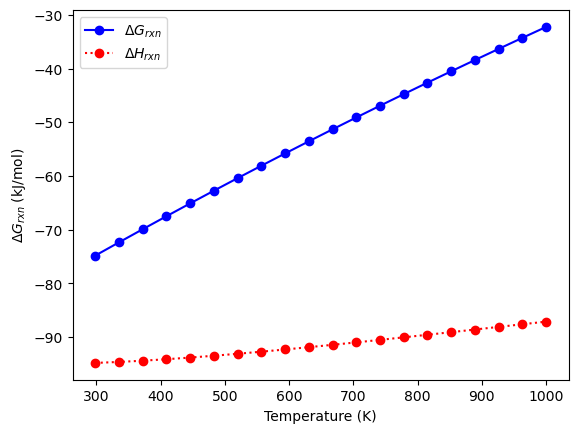

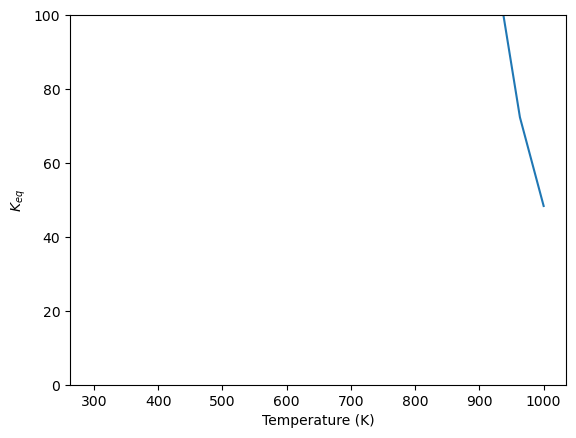

In [1]:
from ase.thermochemistry import IdealGasThermo
from vasp import Vasp
import numpy as np
import matplotlib.pyplot as plt

# first we get the electronic energies
c1 = Vasp(label='molecules/wgs/CO')
E_CO = c1.potential_energy
CO = c1.load_atoms()

c2 = Vasp(label='molecules/wgs/CO2')
E_CO2 = c2.potential_energy
CO2 = c2.load_atoms()

c3 = Vasp(label='molecules/wgs/H2')
E_H2 = c3.potential_energy
H2 = c3.load_atoms()

c4 = Vasp(label='molecules/wgs/H2O')
E_H2O = c4.potential_energy
H2O = c4.load_atoms()

# now we get the vibrational energies
h = 4.1356675e-15  # eV * s
c = 3.0e10  # cm / s

calc = Vasp(label='molecules/wgs/CO-vib')
vib_freq = calc.get_vibrational_frequencies()
CO_vib_energies = [h * c * nu for nu in vib_freq]

calc = Vasp(label='molecules/wgs/CO2-vib')
vib_freq = calc.get_vibrational_frequencies()
CO2_vib_energies = [h * c * nu for nu in vib_freq]

calc = Vasp(label='molecules/wgs/H2-vib')
vib_freq = calc.get_vibrational_frequencies()
H2_vib_energies = [h * c * nu for nu in vib_freq]

calc = Vasp(label='molecules/wgs/H2O-vib')
vib_freq = calc.get_vibrational_frequencies()
H2O_vib_energies = [h * c * nu for nu in vib_freq]

# now we make a thermo object for each molecule
CO_t = IdealGasThermo(vib_energies=CO_vib_energies[0:0],
                      potentialenergy=E_CO, atoms=CO,
                      geometry='linear', symmetrynumber=1,
                      spin=0)

CO2_t = IdealGasThermo(vib_energies=CO2_vib_energies[0:4],
                      potentialenergy=E_CO2, atoms=CO2,
                      geometry='linear', symmetrynumber=2,
                      spin=0)

H2_t = IdealGasThermo(vib_energies=H2_vib_energies[0:0],
                      potentialenergy=E_H2, atoms=H2,
                      geometry='linear', symmetrynumber=2,
                      spin=0)

H2O_t = IdealGasThermo(vib_energies=H2O_vib_energies[0:3],
                      potentialenergy=E_H2O, atoms=H2O,
                      geometry='nonlinear', symmetrynumber=2,
                      spin=0)

# now we can compute G_rxn for a range of temperatures from 298 to 1000 K
Trange = np.linspace(298, 1000, 20)  # K
P = 101325. # Pa
Grxn = np.array([(CO2_t.get_gibbs_energy(temperature=T, pressure=P)
                  + H2_t.get_gibbs_energy(temperature=T, pressure=P)
                  - H2O_t.get_gibbs_energy(temperature=T, pressure=P)
                  - CO_t.get_gibbs_energy(temperature=T, pressure=P)) * 96.485
                 for T in Trange])

Hrxn = np.array([(CO2_t.get_enthalpy(temperature=T)
                  + H2_t.get_enthalpy(temperature=T)
                  - H2O_t.get_enthalpy(temperature=T)
                  - CO_t.get_enthalpy(temperature=T)) * 96.485
                 for T in Trange])

plt.plot(Trange, Grxn, 'bo-', label='$\Delta G_{rxn}$')
plt.plot(Trange, Hrxn, 'ro:', label='$\Delta H_{rxn}$')
plt.xlabel('Temperature (K)')
plt.ylabel(r'$\Delta G_{rxn}$ (kJ/mol)')
plt.legend(loc='best')


plt.figure()
R = 8.314e-3  # gas constant in kJ/mol/K

Keq = np.exp(-Grxn/R/Trange)
plt.plot(Trange, Keq)
plt.ylim([0, 100])
plt.xlabel('Temperature (K)')
plt.ylabel('$K_{eq}$')


You can see a few things here. One is that at near 298K, the Gibbs free energy is about -75 kJ/mol. This is too negative compared to the experimental standard free energy, which we estimated to be about -29 kJ/mol from the [NIST webbook. ](http://matlab.cheme.cmu.edu/2011/12/12/water-gas-shift-equilibria-via-the-nist-webbook/#7)There could be several reasons for this disagreement, but the most likely one is errors in the exchange-correlation functional. The error in energy has a significant effect on the calculated equilibrium constant, significantly overestimating it.

